TP4 - Parte II

Grupo 6: Acosta, Armelini y Freire.

En este Jupyter Notebook resolvemos la Parte II del TP4 de la materia. Clasificación y regularización utilizando la EPH del 1T de 2005 y 2025.

Pregunta 2.1:

"Para cada año,partan la base respondieron en una base de prueba y una de entrenamiento(X_train, y_train, X_test, y_test) utilizando el comando train_test_split. La base de entrenamiento debe comprender el 70% de los datos, y la semilla a utilizar (random state instance) debe ser 101.

Establezca a desocupado como su variable dependiente en la base de entrenamiento (vector y). El resto de las variables serán las variables independientes (matriz X). Recuerden agregar la columna de unos (1)".

Respuesta: en los bloques de código debajo.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

### Carga de base de datos de trabajo
# Se configura la ruta a bases de datos
repo_root = Path.cwd()               # asume que el kernel se lanzó desde la raíz del repo
# Disclaimer: si genera error, se recomienda setear manualmente la ruta del repo y luego proceder con lo de abajo.
data_dir = repo_root / "Datasets"    # subcarpeta 'Datasets' del TP4 del repo

base_predic = pd.read_excel(data_dir / "Base_predic.xlsx")


In [2]:
### FILTRO RESPONDIERON ###

# Vemos los valores únicos de 'ESTADO' para comprobar que la categoría 0 esté formateada correctamente
print(base_predic['ESTADO'].unique())
# Vemos también los tipos de datos de esos valores únicos (esto revela si un 0 es número o texto)
print(base_predic['ESTADO'].apply(type).value_counts())

# Notamos que no hay ningún 0 (o su versión en texto) en la columna 'ESTADO', lo que indica que todos respondieron en el aglomerado en cuestión (Bahía Blanca - Cerri). Por lo tanto, el filtro "respondieron" incluye todos los registros en este caso.
# Para corroborar esto, se chequea la base mergeada y las bases orginales filtradas para el aglomerado. Para ello, cargamos nuevamente las bases mencionadas.
ind_2005 = pd.read_stata(data_dir / "Individual_t105.dta")             # Base Individuos 2005
ind_2005 = ind_2005[ind_2005["aglomerado"] == "Bahía Blanca - Cerri"]  # Filtrado por aglomerado
ind_2005.columns = ind_2005.columns.str.upper()                        # Nombres a mayúsculas
ind_2025 = pd.read_excel(data_dir / "usu_individual_T125.xlsx")        # Base Individuos 2025
ind_2025 = ind_2025[ind_2025["AGLOMERADO"] == 3]                       # Filtrado por aglomerado
base_merged = pd.read_excel(data_dir / "Base_merged.xlsx")             # Base mergeada
print("\n" + "="*20 + "\n")
# Verificamos si ESTADO sigue ahí en la base mergeada
if 'ESTADO' in base_merged.columns:
    print("\nLa columna ESTADO existe.")
    print("Conteo de nulos en ESTADO:", base_merged['ESTADO'].isna().sum())
    # Verificar si el 0 sigue existiendo
    print("Cantidad de ESTADO=0:", (base_merged['ESTADO'] == 0).sum())
else:
    print("\n La columna ESTADO no está.")
    print([col for col in base_merged.columns if 'ESTADO' in col])
# Auditoría de la variable ESTADO en las bases originales ---
print("=== DIAGNÓSTICO BASE INDIVIDUOS 2005 ===")
# 1. Ver qué valores existen y cuántos hay de cada uno
print(ind_2005['ESTADO'].value_counts(dropna=False).sort_index())
# 2. Ver la lista cruda de únicos para detectar textos escondidos (ej: '0' vs 0)
print("Valores únicos (lista):", list(ind_2005['ESTADO'].unique()))
print("\n" + "="*20 + "\n")
print("=== DIAGNÓSTICO BASE INDIVIDUOS 2025 ===")
# 1. Ver qué valores existen y cuántos hay de cada uno
print(ind_2025['ESTADO'].value_counts(dropna=False).sort_index())
# 2. Ver la lista cruda de únicos
print("Valores únicos (lista):", list(ind_2025['ESTADO'].unique()))

[1 3 4 2]
ESTADO
<class 'int'>    1833
Name: count, dtype: int64



La columna ESTADO existe.
Conteo de nulos en ESTADO: 0
Cantidad de ESTADO=0: 0
=== DIAGNÓSTICO BASE INDIVIDUOS 2005 ===
ESTADO
Entrevista individual no realizada (no respuesta al cuestion      0
Ocupado                                                         435
Desocupado                                                       52
Inactivo                                                        457
Menor de 10 años                                                122
Name: count, dtype: int64
Valores únicos (lista): ['Ocupado', 'Inactivo', 'Menor de 10 años', 'Desocupado']


=== DIAGNÓSTICO BASE INDIVIDUOS 2025 ===
ESTADO
1    339
2     16
3    327
4     85
Name: count, dtype: int64
Valores únicos (lista): [np.int64(1), np.int64(3), np.int64(4), np.int64(2)]


In [3]:
# Habiendo chequeado que entonces las bases utilizadas no tienen registros con ESTADO=0 para el aglomerado con el que estamos trabajando, se procede con el resto del análisis con la base de predicción limpia y con variables generadas que resulta de la Parte 1 del TP (Base_predic).

# Para verificación, filtramos y renombramos como respondieron y norespondieron
# Criterio: ESTADO == 0 son los que NO respondieron la condición de actividad
norespondieron = base_predic[base_predic['ESTADO'] == 0].copy()
respondieron = base_predic[base_predic['ESTADO'] != 0].copy()
print(f"=== Reporte de Filtrado ===")
print(f"Total observaciones iniciales: {len(base_predic)}")
print(f"Base 'norespondieron' (ESTADO=0): {len(norespondieron)}")
print(f"Base 'respondieron' (ESTADO!=0): {len(respondieron)} -> Se usará esta para modelar.")


### Limpieza previa al Split Train/Test

# Dejamos de lado los registros con ESTADO = 4. Más info en el documento.
respondieron = respondieron[respondieron['ESTADO'] != 4].copy()


### Split Train/Test para Machine Learning

base_ml = {}

for anio in [2005, 2025]:
    print(f"\n--- Procesando Año {anio} ---")
    
    # a) Filtramos por año sobre la base LIMPIA ('respondieron')
    df_anio = respondieron[respondieron['ANO4'] == anio].copy()
    
    # b) Definimos la Variable Dependiente (y)
    # 1 si es Desocupado (ESTADO==2), 0 en cualquier otro caso (Ocupado o Inactivo)
    df_anio['desocupado'] = (df_anio['ESTADO'] == 2).astype(int)
    y = df_anio['desocupado']
    
    # c) Definimos la Matriz X
    # Se debe sacar 'ESTADO' (porque es la dependiente) y cualquier otra variable que NO deba ser predictora (ej. CAT_OCUP, EMPLEO, CODUSU, PONDERA, etc.).
    vars_a_sacar = [
        'desocupado', 'ESTADO',               # Asociación directa a la respuesta (¡Data Leakage!)
        'CAT_OCUP', 'CAT_INAC', 'EMPLEO', 'SECTOR',
        'PP02A', 'PP02B', 'PP02C1', 'PP02C2', # Preguntas sobre búsqueda de empleo (parte de la
        'PP02C3', 'PP02C4', 'PP02C5',         # definición de desocupado)
        'PP02C6', 'PP02C7', 'PP02C8', 'PP02D', 'PP02E', 'PP02F', 'PP02G', 'PP02H', 'PP02I',
        'PP03C', 'PP03D', 'PP3E_TOT',         # Preguntas solo para ocupados que trabajaron en la
        'PP3F_TOT', 'PP03G', 'PP03H'          # semana de referencia
        'PP03I', 'PP03J', 'PP03K', 'INTENSI', # Preguntas solo para ocupados
        'PP04A', 'PP04A1', 'PP04B_COD', 'PP04B_CAES', 'PP04B1', 'PP04B2', 'PP04B3_MES', 'PP04B3_ANO', 'PP04B3_DIA', 'PP04C', 'PP04C99', 'PP04D_COD', 'PP04G',
        'PP05B2_MES', 'PP05B2_ANO',           # Preguntas para los ocupados imdependientes
        'PP05B2_DIA', 'PP05B3', 'PP05C_1', 'PP05C_2', 'PP05C_3', 'PP05E', 'PP05F', 'PP05H', 'PP05I', 'PP05J', 'PP05K',
        'PP06A', 'PP06C', 'PP06D', 'PP06E',   # Ingresos de ocupados independientes
        'PP06E1', 'PP06H', 'PP06K', 'PP06K_SEM', 'PP06K_MES', 'PP06L',
        'PP07A', 'PP07B1_01', 'PP07C',        # Ocupación de asalariados
        'PP07D', 'PP07E', 'PP07F1', 'PP07F2', 'PP07F3', 'PP07F4', 'PP07F5', 'PP07F1_1', 'PP07F1_2', 'PP07F1_3', 'PP07G1', 'PP07G2', 'PP07G3', 'PP07G4', 'PP07G_59', 'PP07H', 'PP07I', 'PP07I2', 'PP07I3', 'PP07I4', 'PP07J', 'PP07K', 'PP07L', 'PP07M',
        'PP08D1', 'PP08D4', 'PP08F1',         # Ingresos de ocupados asalariados
        'PP08F2', 'PP08G', 'PP08G_DSEM', 'PP08G_DMES', 'PP08H', 'PP08J1', 'PP08J2', 'PP08J3',
        'PP09A', 'PP09A_ESP', 'PP09B',        # Movimientos interurbanos de ocupados
        'PP09C', 'PP09C_ESP',
        'PP10A', 'PP10B1', 'PP10B2',          # Búsqueda de empleo para desocupados
        'PP10B3', 'PP10B4', 'PP10B5', 'PP10B6', 'PP10B7', 'PP10B8', 'PP10B9', 'PP10B10', 'PP10C', 'PP10D', 'PP10E',
        'PP11A', 'PP11B_COD', 'PP11B_CAES',   # Última oocupación/changa de desocupados
        'PP11B1', 'PP1B2_MES', 'PP11B2_ANO', 'PP11B2_DIA', 'PP11C', 'PP11C99', 'PP11D_COD', 'PP11G_ANO', 'PP11G_MES', 'PP11G_DIA', 'PP11L', 'PP11L2', 'PP11M', 'PP11N', 'PP11O', 'PP11P', 'PP11Q', 'PP11R', 'PP11S', 'PP11T',
        'P21', 'DECOCUR', 'IDECOCUR',         # Ingreso de ocupación principal
        'RDECOCUR', 'GDECOCUR', 'PDECOCUR', 'ADECOCUR',
        'TOT_P12',                            # Ingreso otras ocupaciones
        'DECINDR', 'IDECINDR', 'RDECINDR',    # Deciles que producen multicolinealidad con ingresos
        'GDECINDR', 'PDECINDR', 'ADECINDR', 'DECIFR', 'IDECIFR', 'RDECIFR', 'GDECIFR', 'PDECIFR', 'ADECIFR', 'DECCFR', 'IDECCFR', 'RDECCFR', 'GDECCFR', 'PDECCFR', 'ADECCFR', 'P_DECCF', 'P_IDECCF', 'P_RDECCF', 'P_GDECCF', 'P_PDECCF', 'P_ADECCF',
        'V2_01_M', 'V2_02_M', 'V2_03_M',      # Montos de ingresos no laborales (eliminamos estas
        'V3_M', 'V4_M', 'V5_01_M', 'V5_02_M', # pero dejamos el monto total de ing. no lab. y las 
        'V5_03_M', 'V8_M', 'V9_M', 'V10_M',   # variables relevantes para el sostén del hogar de la
        'V11_01_M', 'V11_02_M', 'V12_M',      # sección 'Estrategias del hogar')
        'V18_M', 'V19_AM', 'V21_01_M', 'V22_01_M', 'V21_02_M', 'V22_02_M', 'V21_03_M', 'V22_03_M',
        'PJ1_1', 'PJ2_1', 'PJ3_1',            # Variables del Plan Jefas y Jefes de Hogar que dejaron de ser relevantes
        'CODUSU', 'NRO_HOGAR',                # Identificadores
        'COMPONENTE', 'H15',                  # Identificadores intra-hogar
        'PONDERA', 'PONDII', 'PONDIIO',       # Ponderadores (no se usan como predictores)
        'PONDIH', 'PONDERA_IND', 'PONDERA_HOG',
        'IMPUTA', 'IDIMPH', 'IDIMPP',         # Indicadores de casos imputados
        'TRIMESTRE', 'REGION',                # Indicadores de trimestre y región (ya estamos usando solo un trimestre y una región)
        'MAS_500', 'AGLOMERADO',              # Indicadores de aglomerado (ya estamos filtrando por uno solo)
        'ANO4'                                # El año ya está fijo en el bucle
    ]
    # Quitamos solo las columnas que existan para evitar errores
    cols_drop = [c for c in vars_a_sacar if c in df_anio.columns]
    X = df_anio.drop(columns=cols_drop)
    # Nos quedamos SOLO con columnas numéricas
    X = X.select_dtypes(include=[np.number]).copy()    # Esto elimina columnas de texto como "1er. Trimestre", "Bahía Blanca - Cerri", etc.

    # d) Agregamos la columna de Unos (Intercepto)
    X['intercepto'] = 1
    
    # e) Partición 70/30 con semilla 101
    X_train, X_test, y_train, y_test = train_test_split(   # Comando train_test_split
        X, y, 
        test_size=0.3,     # Proporción de partición para test
        random_state=101   # Semilla (random state instance)
    )
    
    # Guardamos todo en el diccionario
    base_ml[anio] = {
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test
    }
    
    print(f"Dimensiones X_train: {X_train.shape}")
    print(f"Dimensiones X_test:  {X_test.shape}")

=== Reporte de Filtrado ===
Total observaciones iniciales: 1833
Base 'norespondieron' (ESTADO=0): 0
Base 'respondieron' (ESTADO!=0): 1833 -> Se usará esta para modelar.

--- Procesando Año 2005 ---
Dimensiones X_train: (660, 93)
Dimensiones X_test:  (284, 93)

--- Procesando Año 2025 ---
Dimensiones X_train: (477, 93)
Dimensiones X_test:  (205, 93)


Pregunta 2.2:

"Expliquen como elegirían λ por validación cruzada. Detallen por qué no usarían el conjunto de prueba (test) para su elección".

Respuesta: en el documento de texto.

Pregunta 2.3:

"En validación cruzada, ¿cuáles son las implicancias de usar un k muy pequeño o uno muy grande? Cuando k = n (con n el número de muestras), ¿cuántas veces se estima el modelo?".

Respuesta: en el documento de texto.

Pregunta 2.4:

"Implementen la penalidad, L1 como la de LASSO y L2 como la de Ridge, para regresión logística usando la opción penalty y reporten la matriz de confusión, la curva ROC, los valores de AUC y de Accuracy para cada año.
    
[En la tutorial 6, vimos el método de regularización en regresión lineal donde la variable dependiente es numérica. En este caso, nuestra variable dependiente es binaria (ocupado, desocupado), por lo que usamos la regresión logística y aprovechamos la opción de penalidad para aplicar los métodos de regularización vistos en clase.].
    
¿Cómo cambiaron los resultados con respecto al TP3? ¿Mejor o empeoró la performance de regresión logística con regularización?".

Respuesta: en el código debajo y redacción en documento de texto.


==================== ANÁLISIS AÑO 2005 ====================
Columnas originales: 93
Columnas después de limpieza de vacíos: 79

--- Entrenando Lasso (L1) ---


c:\Users\coding\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\coding\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\coding\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_at

Mejor Lambda: 4.281332
Accuracy:     0.9261
AUC:          0.7784
Matriz de Confusión:
[[263   0]
 [ 21   0]]

--- Entrenando Ridge (L2) ---


c:\Users\coding\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\coding\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\coding\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_at

Mejor Lambda: 0.233572
Accuracy:     0.9190
AUC:          0.7192
Matriz de Confusión:
[[260   3]
 [ 20   1]]


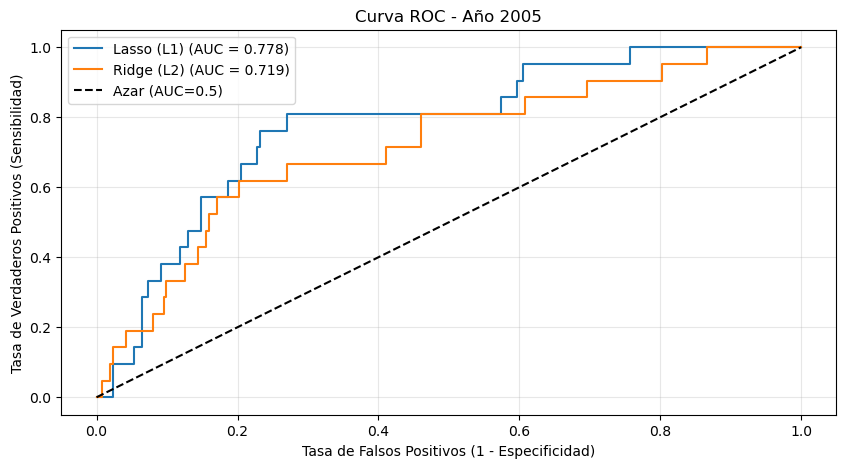


==================== ANÁLISIS AÑO 2025 ====================
Columnas originales: 93
Columnas después de limpieza de vacíos: 87

--- Entrenando Lasso (L1) ---


c:\Users\coding\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\coding\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\coding\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_at

Mejor Lambda: 0.615848
Accuracy:     0.9610
AUC:          0.6656
Matriz de Confusión:
[[197   0]
 [  8   0]]

--- Entrenando Ridge (L2) ---


c:\Users\coding\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\coding\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\coding\anaconda3\envs\bigdata\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_at

Mejor Lambda: 0.000264
Accuracy:     0.9707
AUC:          0.6459
Matriz de Confusión:
[[197   0]
 [  6   2]]


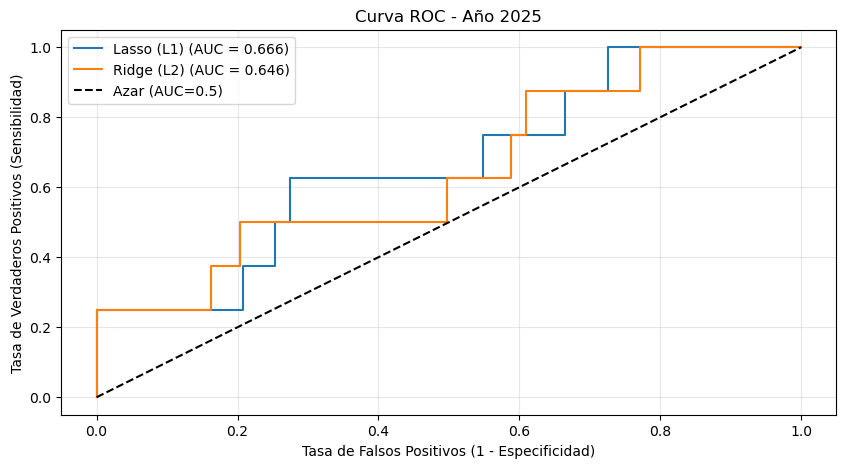

In [ ]:
### Modelos de Regresión Logística Regularizada (Lasso y Ridge) y pasos previos necesarios

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer

# Diccionario para guardar métricas y comparar después
metricas = {}

for anio in [2005, 2025]:
    print(f"\n{'='*20} ANÁLISIS AÑO {anio} {'='*20}")
    
    # 1. Recuperar datos
    X_train_raw = base_ml[anio]['X_train']
    y_train = base_ml[anio]['y_train']
    X_test_raw = base_ml[anio]['X_test']
    y_test = base_ml[anio]['y_test']

    print(f"Columnas originales: {X_train_raw.shape[1]}")

    # 2. Tratamiento de NaNs previo a modelos: Limpieza e Imputación
    ## Limpieza
    # A. Eliminar columnas que sean puramente NaN (vacías)
    # axis=1 (columnas), how='all' (si todos son NaN, borrar)
    X_train_clean1 = X_train_raw.dropna(axis=1, how='all')
    # Alineamos el Test (nos quedamos con las mismas col que sobrevivieron en Train)
    cols_validas = X_train_clean1.columns
    X_test_clean1 = X_test_raw[cols_validas]
    # B. Eliminar columnas con demasiados NaNs (ej. si falta más del 50% de los datos)
    # Esto acelera mucho el modelo y reduce ruido
    umbral = 0.5 * len(X_train_clean1)
    X_train_clean2 = X_train_clean1.dropna(axis=1, thresh=umbral)
    # Alineamos
    cols_finales = X_train_clean2.columns
    X_test_clean2 = X_test_clean1[cols_finales]
    
    print(f"Columnas después de limpieza de vacíos: {X_train_clean2.shape[1]}")

    ## Imputación
    # Usamos la mediana porque es robusta a valores extremos (como ingresos muy altos)
    imputer = SimpleImputer(strategy='median')
    # Usamos DataFrame para no perder nombres de columnas (útil para Lasso)
    # Aprendemos la mediana del Train y rellenamos huecos
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_clean2), columns=cols_finales) 
    # Rellenamos el Test con la mediana del Train (nunca miramos Test para el cálculo)
    X_test_imp = pd.DataFrame(imputer.transform(X_test_clean2), columns=cols_finales)

    # 3. Estandarización (Fundamental para Regularización)
    # Se fitea solo en Train para no filtrar información al Test
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_test_scaled = scaler.transform(X_test_imp)
    
    # Configuramos los modelos a probar (Lasso y Ridge)
    modelos = {
        'Lasso (L1)': {'penalty': 'l1', 'solver': 'saga'},
        'Ridge (L2)': {'penalty': 'l2', 'solver': 'saga'}
    }
    
    plt.figure(figsize=(10, 5))
    
    for nombre, config in modelos.items():
        print(f"\n--- Entrenando {nombre} ---")
        
        # 4. LogisticRegressionCV: Busca el mejor C (lambda) y entrena
        clf = LogisticRegressionCV(
            Cs=20,              # Probamos 10 valores de lambda
            cv=5,               # 5-fold CV
            penalty=config['penalty'],
            solver=config['solver'],
            scoring='roc_auc',  # Optimizamos AUC (mejor para desbalanceados)
            random_state=101,
            max_iter=5000,      # Alto para asegurar convergencia
            tol=0.001           # Relajamos un poco la tolerancia (por defecto es 0.0001) para rapidez
        )
        
        clf.fit(X_train_scaled, y_train)
        
        # 5. Predicciones en Test
        y_pred = clf.predict(X_test_scaled)
        y_prob = clf.predict_proba(X_test_scaled)[:, 1] # Probabilidad de ser clase 1
        
        # 6. Métricas
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        conf_mat = confusion_matrix(y_test, y_pred)
        best_lambda = 1 / clf.C_[0] # Convertimos C a Lambda
        
        # Guardamos para reporte
        print(f"Mejor Lambda: {best_lambda:.6f}")
        print(f"Accuracy:     {acc:.4f}")
        print(f"AUC:          {auc:.4f}")
        print("Matriz de Confusión:")
        print(conf_mat)
        
        # 7. Gráfico Curva ROC (Acumulativo en el mismo plot)
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.3f})")
        
        # (Opcional) Mostrar matriz de confusión visualmente solo para Lasso
        # if config['penalty'] == 'l1':
        #    disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=['Ocup/Inact', 'Desocup'])
        #    disp.plot()
        #    plt.title(f'Matriz Confusión {nombre} - {anio}')
    
    # Configuración final del gráfico ROC del año
    plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC=0.5)')
    plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
    plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
    plt.title(f'Curva ROC - Año {anio}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig(f"Plots/Curva_ROC_{anio}.png")
    plt.show()

Pregunta 2.5:

"Realicen un barrido en λ = 10^n con n ∈ {−5,−4,−3,...,+4,+5} y utilicen 10-fold
CV para elegir el λ óptimo en regresión logística con Ridge y con LASSO. ¿Qué λ
seleccionó en cada caso?

Usando la librería de seaborn, generen box plot mostran
dola distribución del error de predicción para cada λ. Cada box debe corresponder
a un valor de λ y contener como observaciones el error medio de validación para
cada partición.

Además, para la regularización LASSO, generen un line plot, pero
ahora graficando el promedio de la proporción de variables ignoradas por el mode
lo en función de λ, es decir la proporción de variables para las cuales el coeficiente
asociado es cero.

[Hint: a mayor penalidad, esperamos que más coeficientes sean 0, por lo tanto, esta figura debe tener una forma de “S”.]".

Respuesta: en el código debajo y redacción en documento de texto.

Pregunta 2.6:

"En el caso del valor óptimo de λ para LASSO encontrado en el inciso anterior, ¿qué
variables fueron descartadas? ¿Son las que hubieran esperado?

¿Tiene relación con lo que respondieron en el inciso 1 de la Parte I?".

Respuesta: en el código debajo y redacción en documento de texto.

Pregunta 2.7:

"Elijan alguno de los modelos de regresión logística donde hayan probado distintos parámetros de regularización y comenten: comparen los resultados de 2005 versus 2025, ¿qué método de regularización funcionó mejor: Ridge o LASSO?

Comenten mencionando el error cuadrático medio (ECM)".

Respuesta: en el código debajo y redacción en documento de texto.